# Extended Statistical Analysis for Cross-Platform LLM Evaluation

This notebook computes additional statistics to address Reviewer #1's Major Weakness 2:
- **(i)** Confidence intervals across repeated evaluations
- **(ii)** Sensitivity of conclusions to sampling variance
- **(iii)** Whether differences between models are meaningful in practical or statistical terms

---

## ⚠️ Important: Loading Multiple Models

Since all model results have the same filename (`results.json`), you have **3 options**:

| Option | How | Effort | Best For |
|--------|-----|--------|----------|
| **A. ZIP Upload** | ZIP your `results/` folder, upload once | ⭐ Easy | Most users |
| **B. Clone Repo** | Clone directly from GitHub | ⭐ Easy | Public repos |
| **C. Renamed Files** | Rename each `results.json` before upload | 😓 Tedious | Last resort |

**Recommended: Option A (ZIP Upload)**

## 1. Setup

In [ ]:
import numpy as np
from scipy import stats
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os
import zipfile
import io

# Initialize results dict
results = {}

print("✓ Dependencies loaded!")

✓ Dependencies loaded!


---
## 2. Load Data (Choose ONE Option)

### 📦 Option A: Upload ZIP File (Recommended)

**Step 1:** On your computer, create a ZIP of your results folder:
```bash
# Navigate to your repository
cd /path/to/crossplatform-llm

# Create ZIP file
zip -r results.zip results/
```

**Step 2:** Run the cell below and upload the ZIP file

In [ ]:
# ========== OPTION A: Upload ZIP file ==========
from google.colab import files

print("📤 Upload your results.zip file...")
print("   (This should contain your results/ folder with all model subfolders)\n")

uploaded = files.upload()

# Extract ZIP
for filename, content in uploaded.items():
    if filename.endswith('.zip'):
        print(f"\n📂 Extracting {filename}...")
        with zipfile.ZipFile(io.BytesIO(content), 'r') as zip_ref:
            zip_ref.extractall('extracted')
        print("✓ Extraction complete!")
        break
else:
    print("⚠️ No ZIP file found! Please upload a .zip file.")

# Find results directory
RESULTS_DIR = None
for root, dirs, files_list in os.walk('extracted'):
    # Look for directories containing results.json files
    for d in dirs:
        potential_result = os.path.join(root, d, 'results.json')
        if os.path.exists(potential_result):
            RESULTS_DIR = root
            break
    if RESULTS_DIR:
        break

# Fallback: check common paths
if not RESULTS_DIR:
    for path in ['extracted/results', 'extracted', 'results']:
        if os.path.exists(path):
            RESULTS_DIR = path
            break

print(f"\n📁 Results directory: {RESULTS_DIR}")
if RESULTS_DIR:
    subdirs = [d for d in os.listdir(RESULTS_DIR) if os.path.isdir(os.path.join(RESULTS_DIR, d))]
    print(f"   Found {len(subdirs)} model folders")

📤 Upload your results.zip file...
   (This should contain your results/ folder with all model subfolders)



Saving data2.zip to data2.zip

📂 Extracting data2.zip...
✓ Extraction complete!

📁 Results directory: extracted
   Found 2 model folders


### 🔗 Option B: Clone Repository

If your repository is public, you can clone it directly.

In [ ]:
# ========== OPTION B: Clone repository ==========
# Uncomment these lines:

!git clone https://github.com/pablogarciaamolina/crossplatform-llm.git
RESULTS_DIR = "crossplatform-llm/results"  # This is the correct path
print(f"✓ Cloned! Results dir: {RESULTS_DIR}")

Cloning into 'crossplatform-llm'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 50 (delta 9), reused 46 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 705.84 KiB | 5.74 MiB/s, done.
Resolving deltas: 100% (9/9), done.
✓ Cloned! Results dir: crossplatform-llm/results


### 📄 Option C: Upload Renamed JSON Files

If you can't use ZIP, rename each `results.json` to include the model name:
- `Phi-4-mini_results.json`
- `LLaMA-3.1-8B_results.json`
- etc.

In [ ]:
# ========== OPTION C: Upload renamed JSON files ==========
# Uncomment to use:

from google.colab import files
print("📤 Upload your RENAMED JSON files...")
print("   (e.g., Phi-4-mini_results.json, LLaMA-3.1-8B_results.json)\n")
uploaded = files.upload()

for filename, content in uploaded.items():
    if filename.endswith('.json'):
        try:
            data = json.loads(content.decode('utf-8'))
            model_name = data.get('model', filename.replace('.json', '').replace('_results', ''))
            results[model_name] = data
            n_probs = len([e for e in data['evaluations'] if e is not None])
            print(f"✓ {model_name}: {n_probs} problems")
        except Exception as e:
            print(f"✗ Error with {filename}: {e}")

print(f"\n✓ Loaded {len(results)} models")
RESULTS_DIR = None  # Mark that we loaded directly

📤 Upload your RENAMED JSON files...
   (e.g., Phi-4-mini_results.json, LLaMA-3.1-8B_results.json)



Saving reasoning_evaluation_results_nebius_DeepSeek-R1-0528_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_DeepSeek-R1-0528_decurto_and_dezarza_79.json
Saving reasoning_evaluation_results_nebius_gpt-oss-20b_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_gpt-oss-20b_decurto_and_dezarza_79.json
Saving reasoning_evaluation_results_nebius_gpt-oss-120b_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_gpt-oss-120b_decurto_and_dezarza_79.json
Saving reasoning_evaluation_results_nebius_Hermes-4-70B_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_Hermes-4-70B_decurto_and_dezarza_79.json
Saving reasoning_evaluation_results_nebius_Hermes-4-405B_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_Hermes-4-405B_decurto_and_dezarza_79.json
Saving reasoning_evaluation_results_nebius_Llama-3.3-70B-Instruct_decurto_and_dezarza_79.json to reasoning_evaluation_results_nebius_Llama-3.3-70B-Instruct_decurto_and_deza

### Load Results from Directory

In [ ]:
# Load results from directory (for Options A and B)
# Skip this if you used Option C

if RESULTS_DIR and not results:  # Only run if we have a directory and haven't loaded yet
    print(f"📂 Loading results from: {RESULTS_DIR}\n")

    results_path = Path(RESULTS_DIR)

    # Handle NESTED structure: results/org/model/results.json
    # (e.g., results/microsoft/Phi-4-mini-instruct/results.json)
    for org_dir in sorted(results_path.iterdir()):
        if org_dir.is_dir():
            # Check if results.json is directly here (flat structure)
            direct_result = None
            for fname in ["results.json", "improved_reasoning_evaluation_results.json"]:
                if (org_dir / fname).exists():
                    direct_result = org_dir / fname
                    break

            if direct_result:
                # Flat structure: results/model_folder/results.json
                try:
                    with open(direct_result, 'r') as f:
                        data = json.load(f)
                    model_name = data.get('model', org_dir.name)
                    results[model_name] = data
                    n_probs = len([e for e in data['evaluations'] if e is not None])
                    print(f"  ✓ {model_name}: {n_probs} problems")
                except Exception as e:
                    print(f"  ✗ Error: {e}")
            else:
                # Nested structure: results/org/model/results.json
                for model_dir in sorted(org_dir.iterdir()):
                    if model_dir.is_dir():
                        for fname in ["results.json", "improved_reasoning_evaluation_results.json"]:
                            result_file = model_dir / fname
                            if result_file.exists():
                                try:
                                    with open(result_file, 'r') as f:
                                        data = json.load(f)
                                    model_name = data.get('model', f"{org_dir.name}/{model_dir.name}")
                                    results[model_name] = data
                                    n_probs = len([e for e in data['evaluations'] if e is not None])
                                    print(f"  ✓ {model_name}: {n_probs} problems")
                                except Exception as e:
                                    print(f"  ✗ Error: {e}")
                                break

print(f"\n{'='*60}")
print(f"✅ TOTAL MODELS LOADED: {len(results)}")
print(f"{'='*60}")

if len(results) == 0:
    print("\n⚠️ No models loaded!")
    print("Expected: results/<org>/<model>/results.json")
    print("      or: results/<model>/results.json")


✅ TOTAL MODELS LOADED: 9


---
## 3. Helper Functions

In [ ]:
def extract_problem_scores(model_data: dict) -> np.ndarray:
    """Extract per-problem average scores."""
    return np.array([e['average_score'] for e in model_data['evaluations'] if e is not None])

def compute_ci(scores: np.ndarray, confidence: float = 0.95) -> tuple:
    """Parametric confidence interval."""
    n = len(scores)
    if n < 2: return np.mean(scores), np.nan, np.nan, np.nan
    mean, se = np.mean(scores), stats.sem(scores)
    h = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h, se

def bootstrap_ci(scores: np.ndarray, n_boot: int = 10000, conf: float = 0.95) -> tuple:
    """Bootstrap confidence interval."""
    n = len(scores)
    if n < 2: return np.mean(scores), np.nan, np.nan
    rng = np.random.default_rng(42)
    boot = np.array([np.mean(rng.choice(scores, n, replace=True)) for _ in range(n_boot)])
    alpha = 1 - conf
    return np.mean(scores), np.percentile(boot, 100*alpha/2), np.percentile(boot, 100*(1-alpha/2))

def cohens_d(s1: np.ndarray, s2: np.ndarray) -> float:
    """Cohen's d effect size."""
    n1, n2 = len(s1), len(s2)
    if n1 < 2 or n2 < 2: return np.nan
    pooled = np.sqrt(((n1-1)*np.var(s1,ddof=1) + (n2-1)*np.var(s2,ddof=1)) / (n1+n2-2))
    return (np.mean(s1) - np.mean(s2)) / pooled if pooled > 0 else np.nan

def interpret_d(d: float) -> str:
    """Interpret Cohen's d."""
    if np.isnan(d): return "N/A"
    d = abs(d)
    return "negligible" if d < 0.2 else "small" if d < 0.5 else "medium" if d < 0.8 else "large"

def bootstrap_compare(s1: np.ndarray, s2: np.ndarray, n_boot: int = 10000) -> float:
    """P(model1 > model2) via bootstrap."""
    rng = np.random.default_rng(42)
    wins = sum(np.mean(rng.choice(s1, len(s1), True)) > np.mean(rng.choice(s2, len(s2), True))
               for _ in range(n_boot))
    return wins / n_boot

def welch_test(s1: np.ndarray, s2: np.ndarray) -> tuple:
    """Welch's t-test."""
    if len(s1) < 2 or len(s2) < 2: return np.nan, np.nan
    return stats.ttest_ind(s1, s2, equal_var=False)

def compute_icc(data: dict) -> float:
    """Estimate ICC from score variance."""
    evals = [e for e in data['evaluations'] if e is not None]
    if len(evals) < 2: return np.nan
    means = [e['average_score'] for e in evals]
    within_vars = [e['score_std']**2 for e in evals]
    between = np.var(means, ddof=1)
    within = np.mean(within_vars)
    denom = between + within/3
    return between / denom if denom > 0 else np.nan

def leave_one_domain_out(data: dict) -> dict:
    """Mean score excluding each domain."""
    domain_scores = defaultdict(list)
    for p, e in zip(data['problems'], data['evaluations']):
        if e: domain_scores[p['category']].append(e['average_score'])
    result = {}
    for excl in domain_scores:
        remaining = [s for d, scores in domain_scores.items() if d != excl for s in scores]
        if remaining: result[excl] = np.mean(remaining)
    return result

print("✓ Helper functions loaded!")

✓ Helper functions loaded!


---
## 4. Prepare Data

In [ ]:
# Extract scores and sort by performance
model_scores = {name: extract_problem_scores(data) for name, data in results.items()}
sorted_models = sorted(model_scores.keys(), key=lambda m: np.mean(model_scores[m]), reverse=True)

print("📊 Models Ranked by Mean Score:")
print("=" * 65)
for i, m in enumerate(sorted_models, 1):
    scores = model_scores[m]
    print(f"  {i:2d}. {m.split('/')[-1]:<42} {np.mean(scores):.3f} (n={len(scores)})")
print("=" * 65)

📊 Models Ranked by Mean Score:
   1. Hermes-4-70B                               0.598 (n=79)
   2. Hermes-4-405B                              0.573 (n=79)
   3. Meta-Llama-3.1-405B-Instruct               0.560 (n=79)
   4. Llama-3.3-70B-Instruct                     0.516 (n=79)
   5. Qwen3-235B-A22B-Instruct-2507              0.487 (n=79)
   6. Qwen3-30B-A3B-Instruct-2507                0.477 (n=79)
   7. DeepSeek-R1-0528                           0.457 (n=79)
   8. gpt-oss-20b                                0.406 (n=57)
   9. gpt-oss-120b                               0.404 (n=66)


---
## 5. (i) Confidence Intervals

In [ ]:
print("=" * 80)
print("(i) 95% CONFIDENCE INTERVALS")
print("=" * 80)

ci_data = []
for m in sorted_models:
    scores = model_scores[m]
    mean, ci_lo, ci_hi, se = compute_ci(scores)
    _, b_lo, b_hi = bootstrap_ci(scores)
    ci_data.append({
        'Model': m.split('/')[-1][:35],
        'Mean': round(mean, 3),
        'SE': round(se, 3) if not np.isnan(se) else '-',
        '95% CI (Param)': f"[{ci_lo:.3f}, {ci_hi:.3f}]" if not np.isnan(ci_lo) else '-',
        '95% CI (Boot)': f"[{b_lo:.3f}, {b_hi:.3f}]" if not np.isnan(b_lo) else '-'
    })

display(pd.DataFrame(ci_data))

(i) 95% CONFIDENCE INTERVALS


,Model,Mean,SE,95% CI (Param),95% CI (Boot)
0,Hermes-4-70B,0.598,0.025,"[0.548, 0.649]","[0.548, 0.647]"
1,Hermes-4-405B,0.573,0.026,"[0.522, 0.624]","[0.522, 0.622]"
2,Meta-Llama-3.1-405B-Instruct,0.560,0.027,"[0.506, 0.614]","[0.508, 0.614]"
3,Llama-3.3-70B-Instruct,0.516,0.026,"[0.463, 0.568]","[0.465, 0.567]"
4,Qwen3-235B-A22B-Instruct-2507,0.487,0.027,"[0.433, 0.541]","[0.434, 0.540]"
5,Qwen3-30B-A3B-Instruct-2507,0.477,0.027,"[0.424, 0.531]","[0.425, 0.529]"
6,DeepSeek-R1-0528,0.457,0.025,"[0.406, 0.507]","[0.408, 0.505]"
7,gpt-oss-20b,0.406,0.031,"[0.345, 0.467]","[0.348, 0.466]"
8,gpt-oss-120b,0.404,0.027,"[0.350, 0.459]","[0.352, 0.458]"


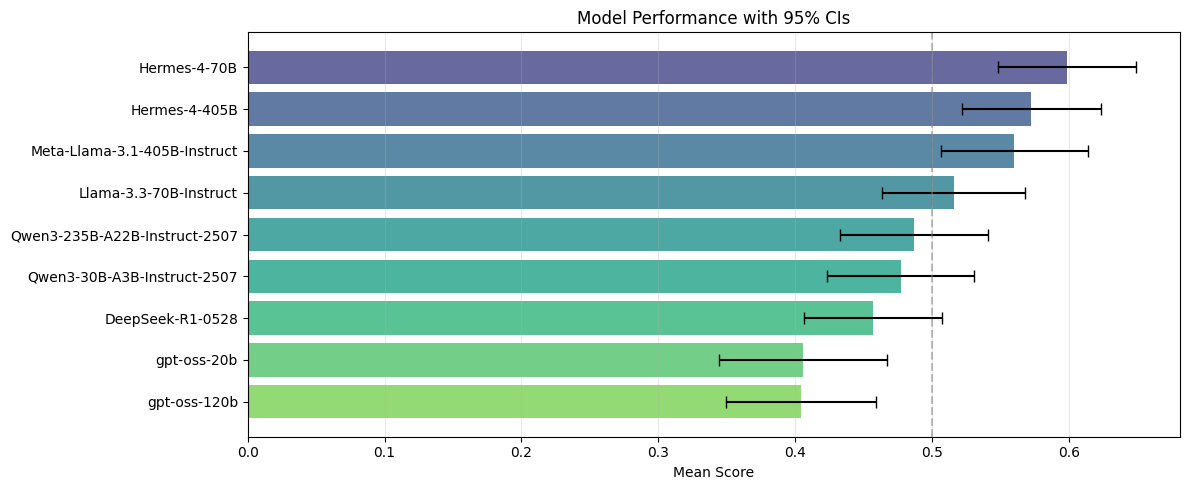

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_models)*0.5)))
y = np.arange(len(sorted_models))
means = [np.mean(model_scores[m]) for m in sorted_models]
cis = [compute_ci(model_scores[m]) for m in sorted_models]
errs = [[m - ci[1] for m, ci in zip(means, cis)], [ci[2] - m for m, ci in zip(means, cis)]]

ax.barh(y, means, xerr=errs, capsize=4, alpha=0.8, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(y))))
ax.set_yticks(y)
ax.set_yticklabels([m.split('/')[-1][:30] for m in sorted_models])
ax.invert_yaxis()
ax.set_xlabel('Mean Score')
ax.set_title('Model Performance with 95% CIs')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. (ii) Sensitivity Analysis

In [ ]:
print("=" * 80)
print("(ii) SENSITIVITY ANALYSIS")
print("=" * 80)

# ICC
print("\n📊 Intraclass Correlation (ICC)")
print("-" * 50)
iccs = []
for m in sorted_models:
    icc = compute_icc(results[m])
    iccs.append(icc)
    if not np.isnan(icc):
        print(f"  {m.split('/')[-1][:42]:<44} ICC = {icc:.3f}")

valid_iccs = [i for i in iccs if not np.isnan(i)]
if valid_iccs:
    print(f"\n  📈 Mean ICC: {np.mean(valid_iccs):.3f} ({np.mean(valid_iccs)*100:.1f}% variance from problem difficulty)")

(ii) SENSITIVITY ANALYSIS

📊 Intraclass Correlation (ICC)
--------------------------------------------------
  Hermes-4-70B                                 ICC = 0.965
  Hermes-4-405B                                ICC = 0.972
  Meta-Llama-3.1-405B-Instruct                 ICC = 0.966
  Llama-3.3-70B-Instruct                       ICC = 0.964
  Qwen3-235B-A22B-Instruct-2507                ICC = 0.993
  Qwen3-30B-A3B-Instruct-2507                  ICC = 0.987
  DeepSeek-R1-0528                             ICC = 0.957
  gpt-oss-20b                                  ICC = 0.965
  gpt-oss-120b                                 ICC = 0.968

  📈 Mean ICC: 0.971 (97.1% variance from problem difficulty)


In [ ]:
# Bootstrap comparisons
print("\n📊 Bootstrap Comparisons (10,000 resamples)")
print("-" * 50)

if len(sorted_models) >= 2:
    top = sorted_models[0]
    top_scores = model_scores[top]
    bootstrap_data = []

    for other in sorted_models[1:]:
        p = bootstrap_compare(top_scores, model_scores[other])
        bootstrap_data.append({'vs': other.split('/')[-1][:25], 'P(top wins)': p})
        sym = "✓" if p > 0.5 else "✗"
        print(f"  {sym} P({top.split('/')[-1][:20]:<20} > {other.split('/')[-1][:20]:<20}) = {p:.3f}")


📊 Bootstrap Comparisons (10,000 resamples)
--------------------------------------------------
  ✓ P(Hermes-4-70B         > Hermes-4-405B       ) = 0.768
  ✓ P(Hermes-4-70B         > Meta-Llama-3.1-405B-) = 0.851
  ✓ P(Hermes-4-70B         > Llama-3.3-70B-Instru) = 0.988
  ✓ P(Hermes-4-70B         > Qwen3-235B-A22B-Inst) = 0.998
  ✓ P(Hermes-4-70B         > Qwen3-30B-A3B-Instru) = 0.999
  ✓ P(Hermes-4-70B         > DeepSeek-R1-0528    ) = 1.000
  ✓ P(Hermes-4-70B         > gpt-oss-20b         ) = 1.000
  ✓ P(Hermes-4-70B         > gpt-oss-120b        ) = 1.000


In [ ]:
# Leave-one-domain-out
print("\n📊 Leave-One-Domain-Out Analysis")
print("-" * 50)

lodo_data = []
if len(sorted_models) >= 2:
    top, second = sorted_models[0], sorted_models[1]
    lodo_top, lodo_second = leave_one_domain_out(results[top]), leave_one_domain_out(results[second])

    if lodo_top and lodo_second:
        print(f"\n  Comparing: {top.split('/')[-1][:30]}")
        print(f"        vs: {second.split('/')[-1][:30]}\n")
        print(f"  {'Excluded':<12} {'Top':>8} {'2nd':>8} {'Δ':>8} {'Winner':>10}")
        print("  " + "-" * 52)

        wins = 0
        for d in sorted(lodo_top.keys()):
            if d in lodo_second:
                delta = lodo_top[d] - lodo_second[d]
                w = "Top ✓" if delta > 0 else "2nd"
                if delta > 0: wins += 1
                print(f"  {d:<12} {lodo_top[d]:>8.3f} {lodo_second[d]:>8.3f} {delta:>+8.3f} {w:>10}")
                lodo_data.append({'Domain': d, 'Top': lodo_top[d], 'Second': lodo_second[d], 'Delta': delta})

        print(f"\n  📈 Top model wins in {wins}/{len(lodo_top)} exclusions ({100*wins/len(lodo_top):.0f}%)")


📊 Leave-One-Domain-Out Analysis
--------------------------------------------------

  Comparing: Hermes-4-70B
        vs: Hermes-4-405B

  Excluded          Top      2nd        Δ     Winner
  ----------------------------------------------------
  Biology         0.596    0.568   +0.028      Top ✓
  Calculus        0.587    0.558   +0.028      Top ✓
  Chemistry       0.600    0.578   +0.022      Top ✓
  Economics       0.590    0.563   +0.027      Top ✓
  Mathematics     0.594    0.579   +0.015      Top ✓
  Optimization    0.616    0.589   +0.026      Top ✓
  Physics         0.599    0.571   +0.028      Top ✓
  Statistics      0.605    0.574   +0.031      Top ✓

  📈 Top model wins in 8/8 exclusions (100%)


---
## 7. (iii) Effect Sizes and Practical Significance

In [ ]:
print("=" * 80)
print("(iii) EFFECT SIZES AND PRACTICAL SIGNIFICANCE")
print("=" * 80)

effect_data = []
if len(sorted_models) >= 2:
    top = sorted_models[0]
    top_scores = model_scores[top]

    print(f"\nReference: {top.split('/')[-1]}")
    print("\nEffect sizes: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, ≥0.8=large\n")

    for other in sorted_models[1:]:
        s = model_scores[other]
        delta = np.mean(top_scores) - np.mean(s)
        d = cohens_d(top_scores, s)
        t, p = welch_test(top_scores, s)

        effect_data.append({
            'Model': other.split('/')[-1][:30],
            'Δ Mean': round(delta, 3),
            "Cohen's d": round(d, 3) if not np.isnan(d) else '-',
            'Effect': interpret_d(d),
            'p-value': f"{p:.4f}" if not np.isnan(p) and p >= 0.0001 else '<0.0001' if not np.isnan(p) else '-'
        })

    display(pd.DataFrame(effect_data))

(iii) EFFECT SIZES AND PRACTICAL SIGNIFICANCE

Reference: Hermes-4-70B

Effect sizes: |d|<0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, ≥0.8=large



,Model,Δ Mean,Cohen's d,Effect,p-value
0,Hermes-4-405B,0.026,0.114,negligible,0.4748
1,Meta-Llama-3.1-405B-Instruct,0.038,0.164,negligible,0.3039
2,Llama-3.3-70B-Instruct,0.083,0.360,small,0.0251
3,Qwen3-235B-A22B-Instruct-2507,0.112,0.478,small,0.0031
4,Qwen3-30B-A3B-Instruct-2507,0.121,0.523,medium,0.0013
5,DeepSeek-R1-0528,0.142,0.629,medium,0.0001
6,gpt-oss-20b,0.192,0.845,large,<0.0001
7,gpt-oss-120b,0.194,0.869,large,<0.0001


In [ ]:
# Practical significance (MPID = 0.05)
MPID = 0.05
print(f"\n📊 Practical Significance (MPID = {MPID})")
print("-" * 50)

if len(sorted_models) >= 2:
    practical = [(m, np.mean(top_scores) - np.mean(model_scores[m]))
                 for m in sorted_models[1:]
                 if abs(np.mean(top_scores) - np.mean(model_scores[m])) >= MPID]

    print(f"\n✓ Practically significant (|Δ| ≥ {MPID}): {len(practical)}")
    for m, d in practical:
        print(f"    vs {m.split('/')[-1][:35]:<37} Δ = {d:+.3f}")

    print(f"\n✗ Not practically significant: {len(sorted_models) - 1 - len(practical)}")


📊 Practical Significance (MPID = 0.05)
--------------------------------------------------

✓ Practically significant (|Δ| ≥ 0.05): 6
    vs Llama-3.3-70B-Instruct                Δ = +0.083
    vs Qwen3-235B-A22B-Instruct-2507         Δ = +0.112
    vs Qwen3-30B-A3B-Instruct-2507           Δ = +0.121
    vs DeepSeek-R1-0528                      Δ = +0.142
    vs gpt-oss-20b                           Δ = +0.192
    vs gpt-oss-120b                          Δ = +0.194

✗ Not practically significant: 2


---
## 8. LaTeX Table

In [ ]:
print("=" * 80)
print("LATEX TABLE - Copy into your manuscript")
print("=" * 80)

latex = r"""\begin{table}[h]
\centering
\caption{Statistical summary with 95\% confidence intervals and effect sizes. CI via bootstrap (10,000 resamples). Cohen's $d$ vs top model.}
\label{t:statistical_summary}
\small
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{Mean} & \textbf{95\% CI} & \textbf{$\Delta$} & \textbf{Cohen's $d$} & \textbf{$p$-value} \\
\midrule
"""

top = sorted_models[0]
top_scores = model_scores[top]

for m in sorted_models:
    s = model_scores[m]
    _, b_lo, b_hi = bootstrap_ci(s)
    name = m.split('/')[-1][:30]

    if m == top:
        latex += f"{name} & {np.mean(s):.3f} & [{b_lo:.3f}, {b_hi:.3f}] & --- & --- & --- \\\\\n"
    else:
        delta = np.mean(top_scores) - np.mean(s)
        d = cohens_d(top_scores, s)
        _, p = welch_test(top_scores, s)
        p_str = "$<$0.001" if p < 0.001 else f"{p:.3f}"
        d_str = f"{d:.2f}" if not np.isnan(d) else "-"
        latex += f"{name} & {np.mean(s):.3f} & [{b_lo:.3f}, {b_hi:.3f}] & ${delta:+.3f}$ & {d_str} & {p_str} \\\\\n"

latex += r"""\bottomrule
\end{tabular}
\end{table}"""

print(latex)

LATEX TABLE - Copy into your manuscript
\begin{table}[h]
\centering
\caption{Statistical summary with 95\% confidence intervals and effect sizes. CI via bootstrap (10,000 resamples). Cohen's $d$ vs top model.}
\label{t:statistical_summary}
\small
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & \textbf{Mean} & \textbf{95\% CI} & \textbf{$\Delta$} & \textbf{Cohen's $d$} & \textbf{$p$-value} \\
\midrule
Hermes-4-70B & 0.598 & [0.548, 0.647] & --- & --- & --- \\
Hermes-4-405B & 0.573 & [0.522, 0.622] & $+0.026$ & 0.11 & 0.475 \\
Meta-Llama-3.1-405B-Instruct & 0.560 & [0.508, 0.614] & $+0.038$ & 0.16 & 0.304 \\
Llama-3.3-70B-Instruct & 0.516 & [0.465, 0.567] & $+0.083$ & 0.36 & 0.025 \\
Qwen3-235B-A22B-Instruct-2507 & 0.487 & [0.434, 0.540] & $+0.112$ & 0.48 & 0.003 \\
Qwen3-30B-A3B-Instruct-2507 & 0.477 & [0.425, 0.529] & $+0.121$ & 0.52 & 0.001 \\
DeepSeek-R1-0528 & 0.457 & [0.408, 0.505] & $+0.142$ & 0.63 & $<$0.001 \\
gpt-oss-20b & 0.406 & [0.348, 0.466] & $+0.192$ & 0.85 & $<$0.001 \

---
## 9. Summary for Reviewer Response

In [ ]:
print("=" * 80)
print("📋 SUMMARY FOR REVIEWER RESPONSE")
print("=" * 80)

n_problems = len(model_scores[sorted_models[0]]) if sorted_models else 0
print(f"\n• Dataset: {len(results)} models, {n_problems} problems\n")

if valid_iccs:
    print(f"• Mean ICC: {np.mean(valid_iccs):.3f} ({np.mean(valid_iccs)*100:.1f}% variance from difficulty)")

all_stds = [e['score_std'] for d in results.values() for e in d['evaluations'] if e]
if all_stds:
    print(f"• Mean within-problem std: {np.mean(all_stds):.3f}")

if len(sorted_models) >= 2:
    p = bootstrap_compare(model_scores[sorted_models[0]], model_scores[sorted_models[1]])
    print(f"• Bootstrap P(top > 2nd): {p*100:.1f}%")

if effect_data:
    ds = [e["Cohen's d"] for e in effect_data if e["Cohen's d"] != '-']
    if ds:
        neg = sum(1 for d in ds if abs(d) < 0.2)
        large = sum(1 for d in ds if abs(d) >= 0.8)
        print(f"• Effect sizes: {neg} negligible, {large} large")

if lodo_data:
    lodo_wins = sum(1 for d in lodo_data if d['Delta'] > 0)
    print(f"• LODO robustness: {lodo_wins}/{len(lodo_data)} domains")

print("\n" + "=" * 80)

📋 SUMMARY FOR REVIEWER RESPONSE

• Dataset: 9 models, 79 problems

• Mean ICC: 0.971 (97.1% variance from difficulty)
• Mean within-problem std: 0.033
• Bootstrap P(top > 2nd): 76.8%
• Effect sizes: 2 negligible, 2 large
• LODO robustness: 8/8 domains



---
## 10. Download Results

In [ ]:
# Save and download
output = {
    'confidence_intervals': ci_data,
    'effect_sizes': effect_data,
    'bootstrap_comparisons': bootstrap_data if 'bootstrap_data' in dir() else [],
    'lodo_analysis': lodo_data,
    'summary': {
        'n_models': len(results),
        'n_problems': n_problems,
        'mean_icc': float(np.mean(valid_iccs)) if valid_iccs else None,
        'mean_within_std': float(np.mean(all_stds)) if all_stds else None
    }
}

with open('extended_statistics.json', 'w') as f:
    json.dump(output, f, indent=2, default=lambda x: float(x) if hasattr(x, 'item') else x)

print("✓ Saved to extended_statistics.json")

from google.colab import files
files.download('extended_statistics.json')

✓ Saved to extended_statistics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>